In [2]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA
import multiprocessing as mp
from multiprocessing import Pool
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier

In [3]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
n_clusters=500
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [4]:
# %%time
# total_path = os.path.join(home_path, '10flies_total_dict.pkl')
# print("Loading total dict")
# with open(total_path, 'rb') as file:
#     total_data_dict = pickle.load(file)

# print(total_data_dict.keys())
# print(total_data_dict['250'].keys())

In [5]:
%%time
total_path = os.path.join(home_path, '10flies_5sec_event_times_split_dic.pkl')
print("Loading best events dict")
with open(total_path, 'rb') as file:
    total_data_dict = pickle.load(file)

print(total_data_dict.keys())
print(total_data_dict['250'].keys())

Loading best events dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['total', 'inc', 'dec', 'flat'])
CPU times: user 2.26 ms, sys: 490 µs, total: 2.75 ms
Wall time: 1.55 s


In [6]:
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files=os.path.join(cluster_dir,file)
giant_total_labels=np.load(label_files)
print(giant_total_labels.shape)

(4171804,)


In [7]:
for i,label in enumerate(giant_total_labels):
    if label==8:
        giant_total_labels[i]=-100
    elif label>8:
        giant_total_labels[i]=label-1

In [8]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
print(giant_labels_anat.shape)

(314, 146, 91)


In [9]:
#ts is in 10ms units

In [10]:
fly_nums=['226','227','228','234','239','240','241','242','249','250']
fly_num=fly_nums[-1]
dff_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/dff'
warp_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/warp'
ch_num=2
for file in os.listdir(dff_path):
    if f'_{ch_num}_' in file:
        file_path=os.path.join(dff_path,file)
for file in os.listdir(warp_path):
    if 'timestamps' in file:
        ts_path=os.path.join(warp_path,file)

In [11]:
%%time
total_path = os.path.join(home_path, 'new_best_5sec_event_times_split_dic.pkl')
print("Loading best events dict")
with open(total_path, 'rb') as file:
    best_data_dict = pickle.load(file)

print(best_data_dict.keys())
print(best_data_dict['250'].keys())

flat_path = os.path.join(home_path, 'new_flat_5sec_event_times_split_dic.pkl')
print("Loading flat events dict")
with open(flat_path, 'rb') as file:
    flat_data_dict = pickle.load(file)

print(flat_data_dict.keys())
print(flat_data_dict['250'].keys())

# old_total = os.path.join(home_path, '10flies_total_dict.pkl')
# print("Loading old dict")
# with open(old_total, 'rb') as file:
#     old_total_dict = pickle.load(file)

# print(old_total_dict.keys())
# print(old_total_dict['250'].keys())

Loading best events dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat', 'non'])
Loading flat events dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['flat'])
CPU times: user 564 µs, sys: 528 µs, total: 1.09 ms
Wall time: 1.59 ms


In [12]:
print(np.shape(best_data_dict['227']['flat']))
print(np.shape(flat_data_dict['227']['flat']))

(133,)
(25,)


In [13]:
count={'inc':0,'dec':0,'flat':0,}
for fly in best_data_dict:
    ci=np.shape(best_data_dict[fly]['inc'])[0]
    cd=np.shape(best_data_dict[fly]['dec'])[0]
    cf=np.shape(best_data_dict[fly]['flat'])[0]
#     cn=np.shape(best_data_dict[fly]['non'])[0]
    count['inc']+=ci
    count['dec']+=cd
    count['flat']+=cf
#     count['non']+=cn
print(f'inc {count["inc"]} dec {count["dec"]} flat {count["flat"]}')
min_count=np.min([count['inc'],count['dec'],count['flat']])

inc 133 dec 144 flat 522


In [14]:
for fly in best_data_dict:
    for b in best_data_dict[fly]:
        if b != 'non':
            num_trials=count[b]
    #         print(num_trials)
            per=min_count/num_trials
    #         print(per)
            num_current=np.shape(best_data_dict[fly][b])[0]
    #         print(num_current)
            thirty=int(num_current*per)
            arr=np.random.choice(np.arange(num_current),thirty,replace=False)
            arr = np.sort(np.asarray(arr).astype(int))
            best_data_dict[fly][b]=np.asarray(best_data_dict[fly][b])[arr]

In [15]:
count_new={'inc':0,'dec':0,'flat':0,}
for fly in best_data_dict:
    ci=np.shape(best_data_dict[fly]['inc'])[0]
    cd=np.shape(best_data_dict[fly]['dec'])[0]
    cf=np.shape(best_data_dict[fly]['flat'])[0]
#     cn=np.shape(best_data_dict[fly]['non'])[0]
    count_new['inc']+=ci
    count_new['dec']+=cd
    count_new['flat']+=cf
#     count_new['non']+=cn
print(f'inc {count_new["inc"]} dec {count_new["dec"]} flat {count_new["flat"]}')

inc 133 dec 129 flat 128


In [16]:
fly_nums=['226','227','228','234','239','240','241','242','249','250']
event_labels={}
for fly in fly_nums:
    event_labels[fly]={}
    trials=np.hstack(list(best_data_dict[fly].values()))
    best_trial_num=np.shape(trials)[0]
#     print(best_trial_num)
    event_labels[fly]['label']=np.full(best_trial_num,str)
    event_labels[fly]['idx']=np.full(best_trial_num,int)
    event_labels[fly]['time']=np.full(best_trial_num,int)
    time=0
    for behave in best_data_dict[fly]:
        for i in range(np.shape(best_data_dict[fly][behave])[0]):
            place=np.where(np.isin(total_data_dict[fly]['total'],best_data_dict[fly][behave][i]))[0][0]
#             print(f'{fly}: {behave}, {place}, {best_data_dict[fly][behave][i]}, {total_data_dict[fly]["total"][place]}')
            event_labels[fly]['label'][time]=behave
            event_labels[fly]['idx'][time]=place
            event_labels[fly]['time'][time]=total_data_dict[fly]['total'][place]
            time+=1
#             print(time)

In [17]:
one=event_labels['226']['idx'].shape[0]
two=event_labels['227']['idx'].shape[0]
print(one)
print(two)
print(one+two)

36
56
92


In [18]:
# test_fly_nums=['226','227','228']#,'234','239']
fly_clust={}
for fly in fly_nums:
    fly_path=os.path.join(home_path,f'{fly}_individual_clusters_ch_2_dict.pkl')
    if os.path.exists(fly_path):
        print(f'fly is {fly}')
        with open(fly_path, 'rb') as file:
            fly_ind_dict = pickle.load(file)
            fly_clust[fly]=fly_ind_dict
    else:
        print('not there yet!')


fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250


In [19]:
fly_clust['228'][1][197].shape

(10,)

In [20]:
%%time
#preload cluster #s
best_events={}
range_r=np.arange(500)
for cluster in range_r:
    if cluster!=8:
        best_events[cluster]={'vals':[],'label':[]}
for fly in fly_clust:
    print(f'fly is {fly}')
    for cluster in fly_clust[fly]:
#         print(f'cluster is {cluster}')
        if cluster!=8:
            for i,event in enumerate(event_labels[str(fly)]['idx']):
    #             print(f'event is {event}, and idx is {i}')
                best_events[cluster]['vals'].append(np.nanmean(fly_clust[fly][cluster][event][1:3]))
                best_events[cluster]['vals'].append(fly_clust[fly][cluster][event][1])
                best_events[cluster]['label'].append(event_labels[str(fly)]['label'][i])

fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250
CPU times: user 9.72 s, sys: 597 ms, total: 10.3 s
Wall time: 9.46 s


In [21]:
sep_events={}
for key in best_events:
    sep_events[key]={}
    labels=np.asarray(best_events[key]['label'])
    labels_idx=np.where((labels == 'inc') | (labels == 'flat') | (labels == 'dec'))
#     print(np.shape(labels_idx))
    data_labels=np.asarray(best_events[key]['label'])[labels_idx]
    data_vals=np.asarray(best_events[key]['vals'])[labels_idx]
    sep_events[key]['vals']=data_vals
    sep_events[key]['label']=data_labels

In [26]:
to_plot_dec=[]
to_plot_inc=[]
to_plot_flat=[]
events=sep_events
# test_clust=np.arange(10,15)
for clust in events:
    data=np.asarray(events[clust]['vals'])
    labels=np.asarray(events[clust]['label'])
    dec=np.where((labels == 'dec'))[0]
    inc=np.where((labels == 'inc'))[0]
    flat=np.where((labels == 'flat'))[0]
    to_plot_dec.append(data[dec])
    to_plot_inc.append(data[inc])
    to_plot_flat.append(data[flat])
    
to_plot_dec=np.hstack(to_plot_dec).reshape(-1,1)
to_plot_inc=np.hstack(to_plot_inc).reshape(-1,1)
to_plot_flat=np.hstack(to_plot_flat).reshape(-1,1)
print(np.shape(to_plot_inc))
print(np.shape(to_plot_dec))
print(np.shape(to_plot_flat))

(66367, 1)
(64371, 1)
(63872, 1)


In [27]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [28]:
all_data = events[clust]['vals']
vmin,vmax=np.nanmin(all_data),np.nanmax(all_data)
vmin,vmax

(-0.2985514, 0.20965752)

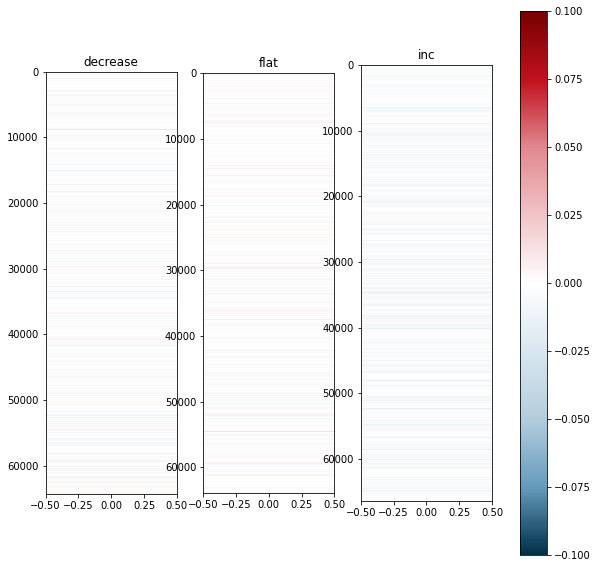

In [29]:
vmin=-0.1
vmax=0.1
ax_ap=0.00005
fig,ax=plt.subplots(1,3,figsize=(10,10))
im1=ax[0].imshow(np.asarray(to_plot_dec), cmap=cmap_personal,vmax=vmax,vmin=-vmax)
ax[0].set_title('decrease')
ax[0].set_aspect(ax_ap)
ax[1].imshow(np.asarray(to_plot_flat), cmap=cmap_personal,vmax=vmax,vmin=-vmax)
ax[1].set_aspect(ax_ap)
ax[1].set_title('flat')
ax[2].imshow(np.asarray(to_plot_inc), cmap=cmap_personal,vmax=vmax,vmin=-vmax)
ax[2].set_aspect(ax_ap)
ax[2].set_title('inc')
fig.colorbar(im1,ax=[ax[0],ax[1],ax[2]])
# plt.tight_layout

In [30]:
np.shape(X)

NameError: name 'X' is not defined

In [31]:
dict_to_look=sep_events
# First, create your full X and y
X = []
y = dict_to_look[0]['label']  # labels should be same across all clusters

for cluster in range(500):
    if cluster!=8:
        X.append(dict_to_look[cluster]['vals'])

X = np.vstack(X).T  # Transpose to get (n_trials, n_clusters)
print(np.shape(X))
y = np.array(y)
print(np.shape(y))

# Do ONE train/test split for all trials
train_indices, test_indices = train_test_split(
    np.arange(len(y)), 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print(np.shape(train_indices),np.shape(test_indices))
# Now evaluate each cluster individually
train_scores = []
test_scores = []
model = LogisticRegression(max_iter=1000, multi_class='multinomial',C=10)
for cluster in range(np.shape(X)[-1]):
    # Get this cluster's data
    X_cluster = X[:, cluster].reshape(-1, 1)

    # Split using the same indices
    X_train = X_cluster[train_indices]
    X_test = X_cluster[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fit model
    model.fit(X_train_scaled, y_train)

    # Get scores
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

train_scores = np.array(train_scores)
test_scores = np.array(test_scores)

(390, 499)
(390,)
(312,) (78,)


In [32]:
print(np.max(train_scores),np.max(test_scores))

0.4166666666666667 0.47435897435897434


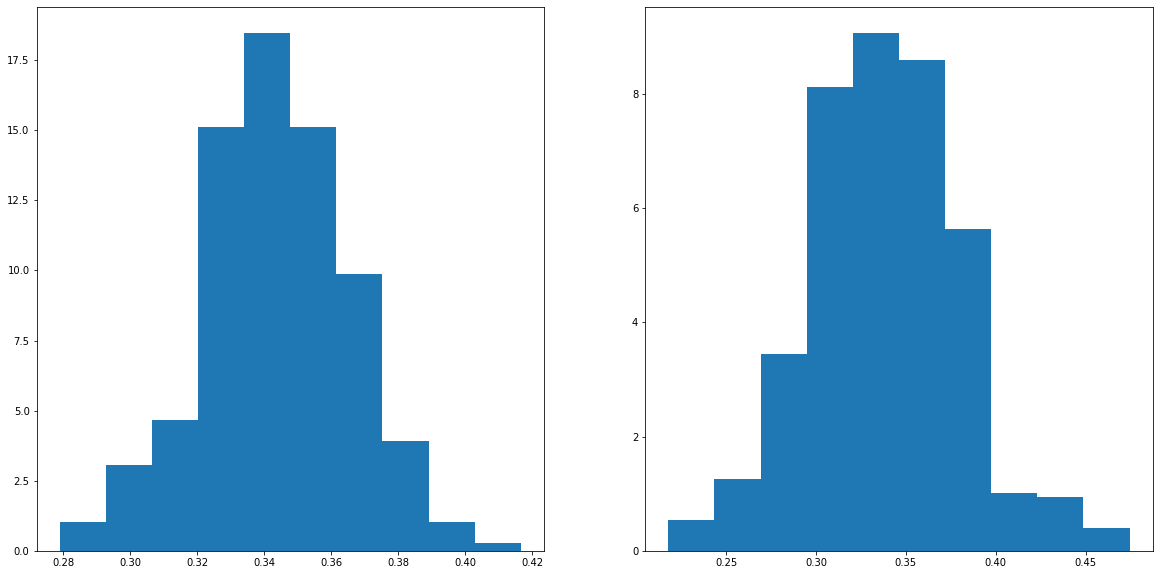

In [33]:
fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].hist(train_scores, bins=10,density=True);
# ax[0].set_ylim(0,10);
# ax[0].set_xlim(0,1);
ax[1].hist(test_scores, bins=10, density=True);
# ax[1].set_ylim(0,10);
# ax[1].set_xlim(0,1);


In [34]:
# Find best parameters using cross-validation
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    rf, 
    param_grid, 
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X[train_indices], y[train_indices])

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

# Use best model
best_rf = grid_search.best_estimator_

train_acc = best_rf.score(X[train_indices], y[train_indices])
test_acc = best_rf.score(X[test_indices], y[test_indices])

print(f"\nOptimized Random Forest:")
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

# Get importance from best model
importances = best_rf.feature_importances_

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV score: 0.651

Optimized Random Forest:
Train accuracy: 1.000
Test accuracy: 0.692


In [35]:
%%time
null_scores_total=[]
train_acc_total=[]
test_acc_total=[]
y_predict_total=[]
y_idxs=[]
top_100=[]
top_importances=[]
num_permutations=10
for i in range(num_permutations):
    train_indices, test_indices = train_test_split(
    np.arange(len(y)), 
    test_size=0.2, 
    random_state=i, 
    stratify=y
    )
    # 1. Basic Random Forest
    rf = RandomForestClassifier(
        n_estimators=200,      # number of trees
        max_depth=6,          # max depth of each tree (prevents overfitting)
        min_samples_split=5,   # minimum samples to split a node
        min_samples_leaf=1,    # minimum samples in leaf
        random_state=i,
        n_jobs=-1              # use all CPU cores
    )

    # Fit model
    rf.fit(X[train_indices], y[train_indices])
    
    # Evaluate
    train_acc = rf.score(X[train_indices], y[train_indices])
    train_acc_total.append(train_acc)
    test_acc = rf.score(X[test_indices], y[test_indices])
    test_acc_total.append(test_acc)
    num_lab = len(y[test_indices]) 
    y_null=np.random.choice(list(rf.classes_), size=num_lab)
    null_acc = rf.score(X[test_indices], y_null)
    null_scores_total.append(null_acc)
    y_pred = rf.predict(X[test_indices])
    y_predict_total.append(y_pred)
    y_idxs.append(y[test_indices])
    top_100_idx=np.argsort(rf.feature_importances_)[::-1][:100]
    top_100.append(top_100_idx)
    top_importances.append(rf.feature_importances_[top_100_idx])
null_acc_final=np.mean(null_scores_total)
train_acc_final=np.mean(train_acc_total)
test_acc_final=np.mean(test_acc_total)
# y_predict_final=np.mean(y_predict_total)

print(f"Random Forest Performance:")
print(f"Train accuracy: {train_acc_final:.3f}, std: {np.std(train_acc_total)}")
print(f"Test accuracy: {test_acc_final:.3f}, std: {np.std(test_acc_total)}")
# print(f"Null accuracy: {null_acc_final:.3f}, std: {np.std(null_scores)}")


Random Forest Performance:
Train accuracy: 0.994, std: 0.0009615384615384581
Test accuracy: 0.622, std: 0.05168113941217019
CPU times: user 7.69 s, sys: 912 ms, total: 8.61 s
Wall time: 9.23 s


In [36]:
y_predict_final=np.hstack(y_predict_total)
y_idxs_final=np.hstack(y_idxs)

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

# y_pred = rf.predict(X[test_indices])
print("\nTest Set Classification Report:")
print(classification_report(y_predict_final, y_idxs_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_predict_final, y_idxs_final))


Test Set Classification Report:
              precision    recall  f1-score   support

         dec       0.53      0.61      0.57       226
        flat       0.69      0.63      0.66       280
         inc       0.65      0.62      0.64       274

    accuracy                           0.62       780
   macro avg       0.62      0.62      0.62       780
weighted avg       0.63      0.62      0.62       780


Confusion Matrix:
[[138  38  50]
 [ 61 176  43]
 [ 61  42 171]]


In [38]:
ids,counts=np.unique(top_100, return_counts=True)
top_ids=ids[np.argsort(counts)[::-1]][:100]
top_counts=counts[np.argsort(counts)[::-1]][:100]

In [39]:
top_100=np.asarray(top_100)
new_importances={}
for i in top_ids:
    new_importances[i]=[]
for i in top_ids:
#     print(i)
    for j,x in enumerate(top_importances):
#         print(j)
        importance_vals=x
        val=importance_vals[np.isin(top_100[j,:],i)]
        new_importances[i].append(val)
    new_importances[i]=np.hstack(new_importances[i])

In [40]:
top_importances_final=[]
for ids in new_importances:
    top_importances_final.append(np.mean(new_importances[ids]))
top_importances_final=np.asarray(top_importances_final)

In [41]:
order=np.argsort(top_importances_final)[::-1]
ids=top_ids[order]
count=top_counts[order]
importance=top_importances_final[order]

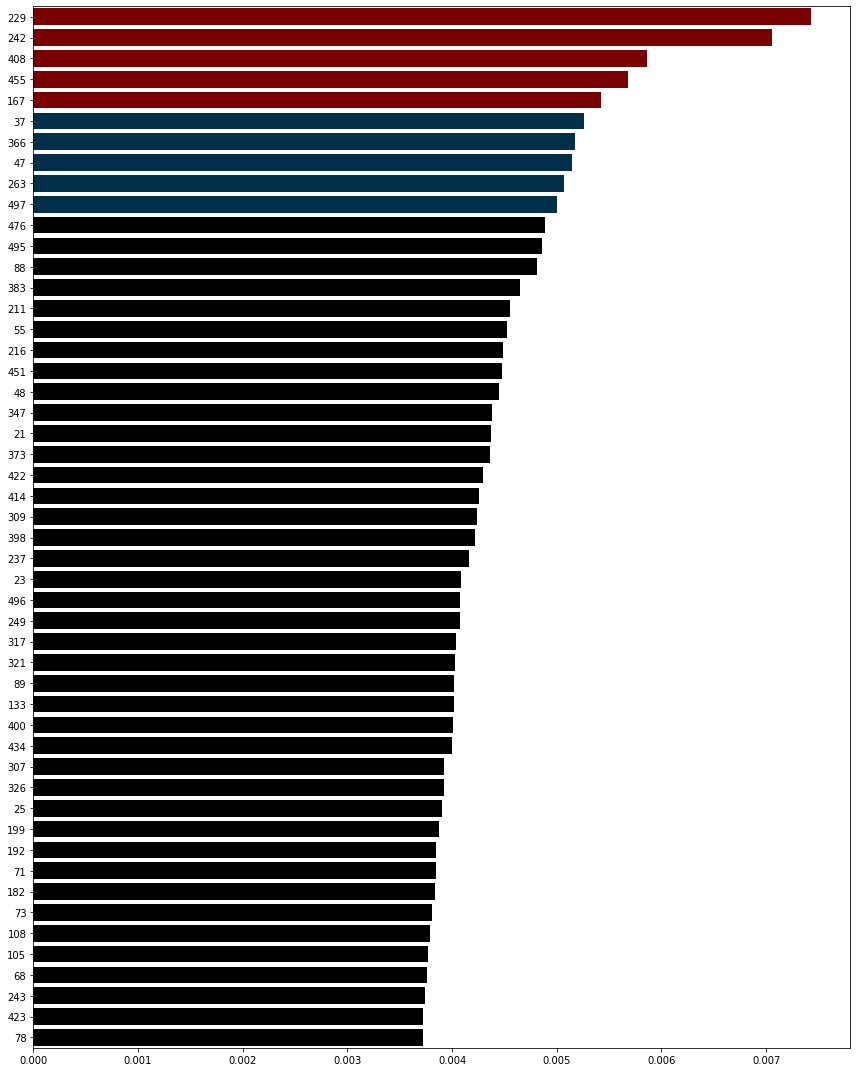

In [42]:
# Plot feature importances
amt=50
top_num1=5
top_num2=10
fig_height = max(8, amt * 0.3) 
plt.figure(figsize=(12, fig_height))
positions = np.arange(amt)
color_bar=np.full(amt,'#000000')
color_bar[:top_num1]='#780000'
color_bar[top_num1:top_num2]='#003049'
# top = importance_df.head(amt)
plt.barh(positions,importance[:amt],color=color_bar)
plt.yticks(positions,ids[:amt])
# plt.xlabel('Importance')
# plt.ylabel('Cluster ID')
# plt.title(f'Top {amt} Most Important Clusters')
plt.gca().invert_yaxis()
plt.ylim(amt - 0.5, -0.5)

# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_bar.png'), dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [43]:
def create_dark_to_color_cmap(color):
    """Create colormap from black to specified color"""
    return matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#FFADAD',color,color,color,color,color]) #'#70CDFF'

In [44]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape
anat_uint=anat_high_res.astype('uint8')

In [289]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')


(1256, 584, 363)


In [290]:
nx,ny,nz=atlas.shape
ox,oy,oz=giant_labels_anat.shape
# scale_factors = (nx/ox, ny/oy, nz/oz)
scale_factors = (ox/nx, oy/ny, oz/nz)
# Resample using zoom with cubic interpolation (order=3)
anat_lowres = zoom(anat_high_res, scale_factors, order=3)
atlas_lowres = zoom(atlas_int, scale_factors, order=3)

In [291]:
print(anat_lowres.shape)
# atlas_int = anat_lowres.astype('uint8')

(314, 146, 91)


(499,)


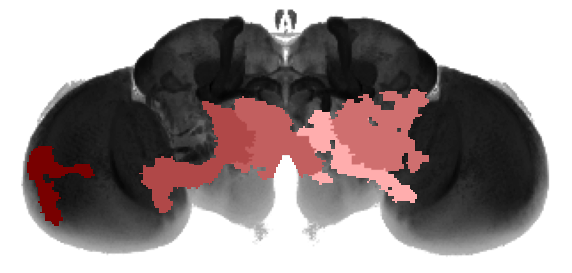

In [322]:
amt=5
print(np.shape(cluster_importances[b]))
fig,ax=plt.subplots(figsize=(10,10))
plt.imshow(np.max(anat_lowres, axis=-1).T,cmap='gray_r');
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,ids[:amt]),giant_labels_anat,np.nan)
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=create_dark_to_color_cmap('#780000'))
ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_loc.png'), dpi=300, bbox_inches='tight')

In [310]:
roi_atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [311]:
def explode_plot(brain,vmax,explosion_rois,roi_masks,roi_contours,tp=None,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    if tp==None:
        data_to_plot = brain[:,:,::-1]
    else:
        data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=False)#'hot')
    return explosion_map

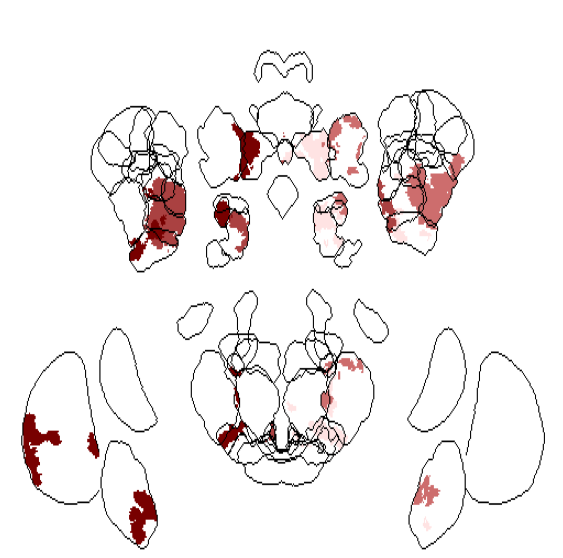

In [326]:
ax_as=1.5
vmax=np.nanmax(labels_anat_sub_total)
fig,axs=plt.subplots(figsize=(10,10))
temp=explode_plot(np.nan_to_num(labels_anat_sub_total),vmax,explosion_rois,roi_masks,roi_contours,cmap=create_dark_to_color_cmap('#780000'))
brain=axs.imshow(temp[170:,:]) #this was made with cmap=hot
axs.axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
axs.set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'top{amt}_explosion.png'), dpi=300, bbox_inches='tight')

In [198]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

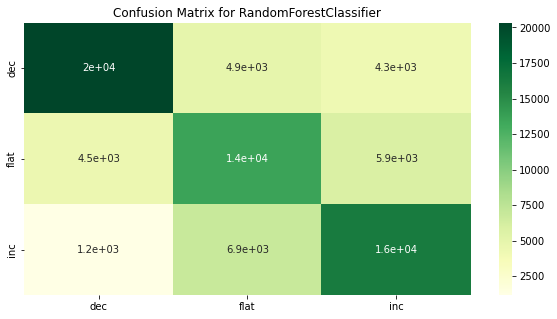

In [200]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(confusion_matrix(y_predict_final, y_idxs_final), ax=ax, cmap='YlGn', annot=True)
ax.xaxis.set_ticklabels(rf.classes_)
ax.yaxis.set_ticklabels(rf.classes_)
_ = ax.set_title(
    f"Confusion Matrix for {rf.__class__.__name__}"
)

# plt.savefig(os.path.join(save_dir,f'confusion_matrix_{rf.__class__.__name__}.png'), dpi=300, bbox_inches='tight')


Top 20 Most Important Clusters:
     cluster  importance  single_test_acc
229      229    0.009980         0.282051
347      347    0.007771         0.384615
495      495    0.007245         0.320513
167      167    0.006322         0.307692
373      373    0.005826         0.307692
376      376    0.005822         0.294872
408      408    0.005781         0.371795
249      249    0.005742         0.371795
466      466    0.005454         0.423077
130      130    0.005331         0.320513
455      455    0.005310         0.346154
47        47    0.004926         0.294872
476      476    0.004872         0.410256
243      243    0.004850         0.294872
133      133    0.004756         0.294872
88        88    0.004717         0.346154
275      275    0.004674         0.346154
87        87    0.004522         0.307692
242      242    0.004418         0.333333
389      389    0.004376         0.282051


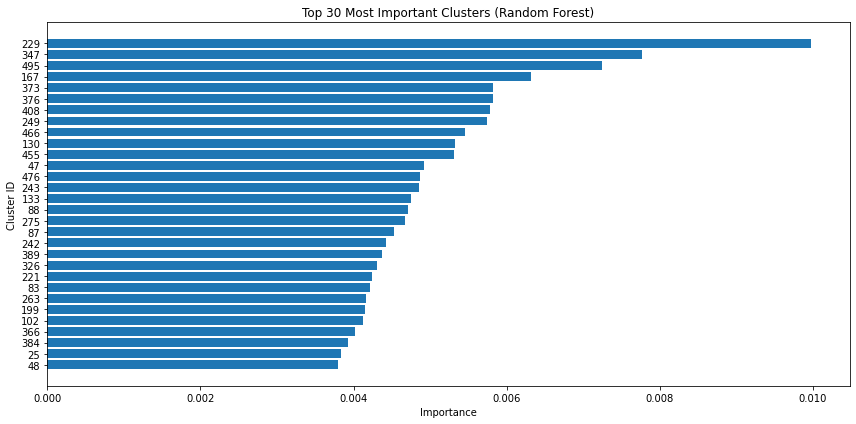

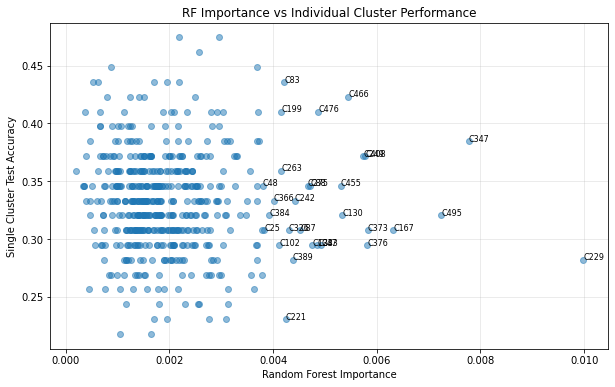

In [45]:
importances = rf.feature_importances_

# Create dataframe with cluster importance
importance_df = pd.DataFrame({
    'cluster': range(499),
    'importance': importances,
    'single_test_acc': test_scores  # from your earlier analysis
})

# Sort by importance
importance_df = importance_df.sort_values('importance', ascending=False)

print("Top 20 Most Important Clusters:")
print(importance_df.head(20))

# Plot feature importances
plt.figure(figsize=(12, 6))
top_30 = importance_df.head(30)
plt.barh(range(30), top_30['importance'].values)
plt.yticks(range(30), top_30['cluster'].values)
plt.xlabel('Importance')
plt.ylabel('Cluster ID')
plt.title('Top 30 Most Important Clusters (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Compare: RF importance vs single-cluster accuracy
plt.figure(figsize=(10, 6))
plt.scatter(importance_df['importance'], 
            importance_df['single_test_acc'], 
            alpha=0.5)
plt.xlabel('Random Forest Importance')
plt.ylabel('Single Cluster Test Accuracy')
plt.title('RF Importance vs Individual Cluster Performance')
plt.grid(True, alpha=0.3)

# Annotate top clusters
top_30 = importance_df.head(30)
for _, row in top_30.iterrows():
    plt.annotate(f"C{int(row['cluster'])}", 
                xy=(row['importance'], row['single_test_acc']),
                fontsize=8)

In [30]:
ovr_rf = OneVsRestClassifier(rf)

ovr_rf.fit(X[train_indices], y[train_indices])

OneVsRestClassifier(estimator=RandomForestClassifier(max_depth=6,
                                                     min_samples_split=5,
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42))

In [31]:
class_names = list(rf.classes_)
class_importances = {}
cluster_importances= {}

for idx, (class_name, estimator) in enumerate(zip(class_names, ovr_rf.estimators_)):
    importances = estimator.feature_importances_
    class_importances[class_name] = importances
    cluster_importances[class_name]=[]
    
    # Top 10 for this class
    top_10_idx = np.argsort(importances)[::-1]
#     print(f"\nTop 5 clusters for '{class_name}':")
    for rank, cluster in enumerate(top_10_idx, 1):
#         print(f"  {rank}. Cluster {cluster}: {importances[cluster]:.4f}")
#         class_importances[class_name]['clusters'].append(cluster)
        cluster_importances[class_name].append(cluster)

# Create DataFrame
importance_df_class = pd.DataFrame(class_importances)
importance_df_class['cluster'] = range(np.shape(X)[-1])

In [32]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#727272',
    'un':'orange'
}

In [33]:
clust_by_behave={}
amt=100
for b in list(rf.classes_):
    clust_by_behave[b]=[]
clusters = importance_df.head(amt)['cluster'].values
behavior_cols = [col for col in importance_df_class.columns if col != 'cluster']
for clus in clusters:
#     print(clus)
    clus_to_look=importance_df_class[importance_df_class['cluster'] == clus]
    id_max=clus_to_look[behavior_cols].iloc[0].idxmax()
    clust_by_behave[id_max].append(clus)
#     num=10
#     mask=np.isin(importance_df.head(10),list(importance_df_class.sort_values(by=b, ascending=False).head(num)['cluster']))
#     clust_by_behave[b]=np.asarray(importance_df.head(10))[mask]

In [34]:
cl=np.asarray(importance_df.head(amt)['cluster'].values)
color_bars=np.full(np.shape(cl),str)
for i,c in enumerate(cl):
    for b in clust_by_behave:
        if np.isin(clust_by_behave[b],c).any():
            color_bars[i]=behavior_colors[b]
    

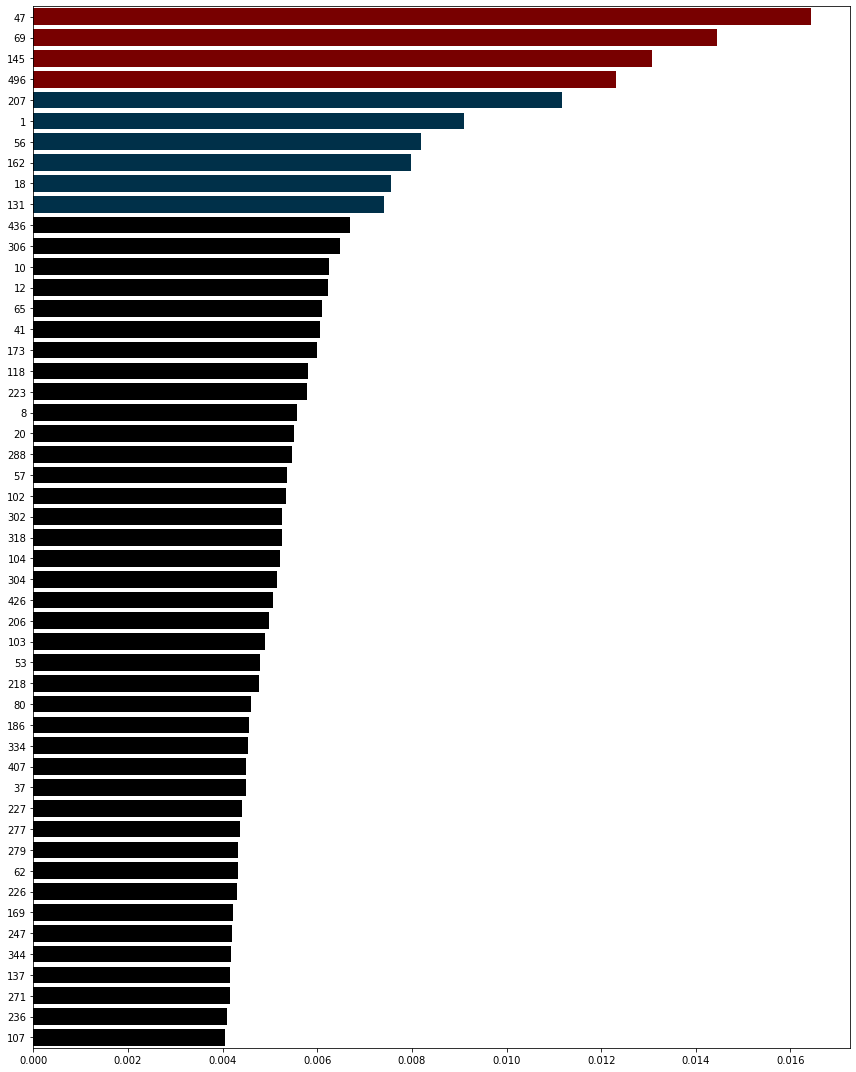

In [201]:
# Plot feature importances
amt=50
top_num1=4
top_num2=10
fig_height = max(8, amt * 0.3) 
plt.figure(figsize=(12, fig_height))
positions = np.arange(amt)
color_bar=np.full(amt,'#000000')
color_bar[:top_num1]='#780000'
color_bar[top_num1:top_num2]='#003049'
top = importance_df.head(amt)
plt.barh(positions, top['importance'].values,color=color_bar)
plt.yticks(positions, top['cluster'].values)
# plt.xlabel('Importance')
# plt.ylabel('Cluster ID')
# plt.title(f'Top {amt} Most Important Clusters')
plt.gca().invert_yaxis()
plt.ylim(amt - 0.5, -0.5)

# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_bar.png'), dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [202]:
def create_dark_to_color_cmap(color):
    """Create colormap from black to specified color"""
    return matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#70CDFF',color,color,color,color]) #'#FFADAD'

In [203]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape
anat_uint=anat_high_res.astype('uint8')

In [204]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')


(1256, 584, 363)


In [205]:
nx,ny,nz=atlas.shape
ox,oy,oz=giant_labels_anat.shape
# scale_factors = (nx/ox, ny/oy, nz/oz)
scale_factors = (ox/nx, oy/ny, oz/nz)
# Resample using zoom with cubic interpolation (order=3)
anat_lowres = zoom(anat_high_res, scale_factors, order=3)
atlas_lowres = zoom(atlas_int, scale_factors, order=3)

In [206]:
print(anat_lowres.shape)
# atlas_int = anat_lowres.astype('uint8')

(314, 146, 91)


(499,)


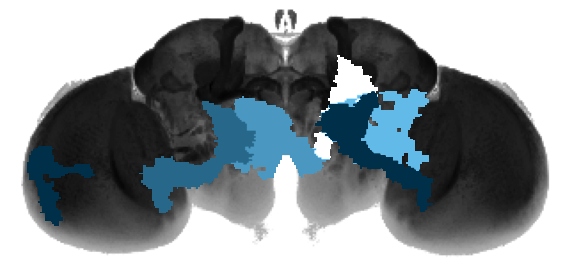

In [247]:
amt=6
print(np.shape(cluster_importances[b]))
fig,ax=plt.subplots(figsize=(10,10))
plt.imshow(np.max(anat_lowres, axis=-1).T,cmap='gray_r');
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_ids[:amt]),giant_labels_anat,np.nan)
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=create_dark_to_color_cmap('#003049'))
ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_loc.png'), dpi=300, bbox_inches='tight')

In [217]:
roi_atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [218]:
def explode_plot(brain,vmax,explosion_rois,roi_masks,roi_contours,tp=None,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    if tp==None:
        data_to_plot = brain[:,:,::-1]
    else:
        data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=False)#'hot')
    return explosion_map

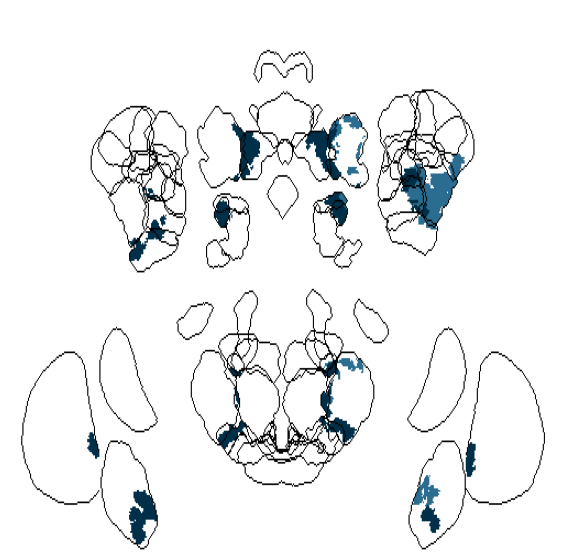

In [219]:
ax_as=1.5
vmax=np.nanmax(labels_anat_sub_total)
fig,axs=plt.subplots(figsize=(10,10))
temp=explode_plot(np.nan_to_num(labels_anat_sub_total),vmax,explosion_rois,roi_masks,roi_contours,cmap=create_dark_to_color_cmap('#003049'))
brain=axs.imshow(temp[170:,:]) #this was made with cmap=hot
axs.axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
axs.set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'top{amt}_explosion.png'), dpi=300, bbox_inches='tight')

In [45]:
clust_by_behave_other={}
amt=200
for b in list(rf.classes_):
    num=200
    mask=np.isin(importance_df.head(amt),list(importance_df_class.sort_values(by=b, ascending=False).head(num)['cluster']))
    clust_by_behave_other[b]=np.asarray(importance_df.head(amt))[mask]
clusters = importance_df.head(amt)['cluster'].values
not_in=~np.isin(clusters,np.hstack(list(clust_by_behave_other.values())))
val_not_in=clusters[not_in]
# print(val_not_in)
clust_by_behave_other['un']=val_not_in

In [46]:
np.unique(np.hstack(list(clust_by_behave.values()))).shape

(100,)

In [47]:
fixed = brainsss.load_fda_meanbrain()

In [48]:
giant_total_labels.shape

(4171804,)

(499,)


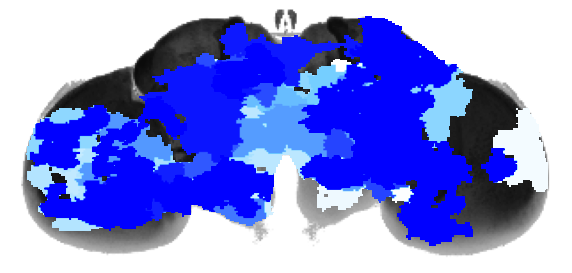

In [50]:
amt=50
b='inc'
print(np.shape(cluster_importances[b]))
fig,ax=plt.subplots(figsize=(10,10))
plt.imshow(np.max(anat_lowres, axis=-1).T,cmap='gray_r');
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,cluster_importances[b][:amt]),giant_labels_anat,np.nan)
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=create_dark_to_color_cmap('b'))
ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'top{amt}_{b}_cluster_loc.png'), dpi=300, bbox_inches='tight')

In [51]:
labels_anat_sub_total.shape

(314, 146, 91)

In [52]:
roi_atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [53]:
def explode_plot(brain,vmax,explosion_rois,roi_masks,roi_contours,tp=None,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    if tp==None:
        data_to_plot = brain[:,:,::-1]
    else:
        data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=False)#'hot')
    return explosion_map

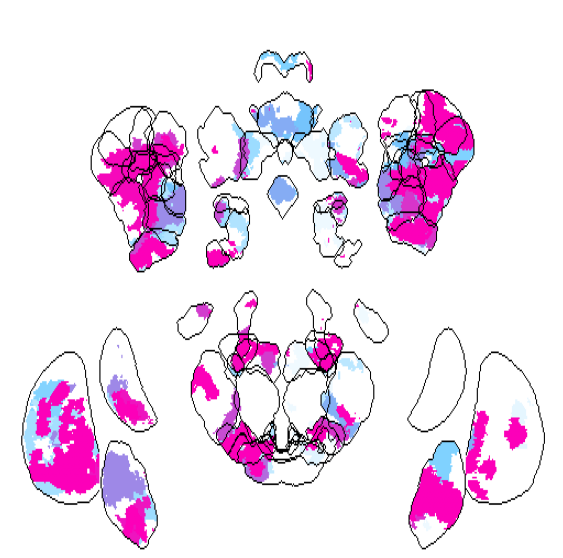

In [54]:
ax_as=1.5
vmax=np.nanmax(labels_anat_sub_total)
fig,axs=plt.subplots(figsize=(10,10))
temp=explode_plot(np.nan_to_num(labels_anat_sub_total),vmax,explosion_rois,roi_masks,roi_contours,cmap=create_dark_to_color_cmap(behavior_colors[b]))
brain=axs.imshow(temp[170:,:]) #this was made with cmap=hot
axs.axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
axs.set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'top{amt}_{b}_explosion.png'), dpi=300, bbox_inches='tight')

In [58]:
b1='inc'
b2='flat'
b3='dec'
# b4='non'
b1_b=np.asarray(cluster_importances[b1][:50])
b2_b=np.asarray(cluster_importances[b2][:50])
b3_b=np.asarray(cluster_importances[b3][:50])
# b4_b=np.asarray(cluster_importances[b4][:50])
total_b=[b1_b.flatten().astype(int),b2_b.flatten().astype(int),b3_b.flatten().astype(int)] #,b4_b.flatten().astype(int)
common_values=reduce(np.intersect1d,total_b)
b1_uncommon=b1_b[~np.isin(b1_b,common_values)]
b2_uncommon=b2_b[~np.isin(b2_b,common_values)]
b3_uncommon=b3_b[~np.isin(b3_b,common_values)]


In [59]:
common_values

array([12, 62, 69])

In [60]:
print(b1_uncommon)
print(b2_uncommon)
print(b3_uncommon)
print(common_values)

[304 421 131  89 104 162 173 316 496 206  56 218 377 379  19 306  86  22
 169 236 211 277 205 147 373 319 114 189  47 115  53 284  11  49  41 258
 360 210 195 288 194 133 413 334 455  87  10]
[  1 306 186 465 479 368 472 474  80   8 473 377  20 207 155 101 141 267
 437  24 214 477 289   2  65 205 165 204 179 392 424 118 332 277 194 114
  37  31  73 348 387 142  15  42 189 417 228]
[  1  56 145 104 131 207 318  47 421   8 334 107 137 435  65 162 425 103
 186  37 378 496  43 298  86  40  95 474 195 364 115 367 235 244  20 266
  18 101 223 271 477 407  14 118 146 426 123]
[12 62 69]


In [61]:
print(np.sort(b1_b))
print(np.sort(b2_b))
print(np.sort(b3_b))

[ 10  11  12  19  22  41  47  49  53  56  62  69  86  87  89 104 114 115
 131 133 147 162 169 173 189 194 195 205 206 210 211 218 236 258 277 284
 288 304 306 316 319 334 360 373 377 379 413 421 455 496]
[  1   2   8  12  15  20  24  31  37  42  62  65  69  73  80 101 114 118
 141 142 155 165 179 186 189 194 204 205 207 214 228 267 277 289 306 332
 348 368 377 387 392 417 424 437 465 472 473 474 477 479]
[  1   8  12  14  18  20  37  40  43  47  56  62  65  69  86  95 101 103
 104 107 115 118 123 131 137 145 146 162 186 195 207 223 235 244 266 271
 298 318 334 364 367 378 407 421 425 426 435 474 477 496]


In [62]:
total_b1=b2_b[~np.isin(b2_b,common_values)]
# common_values=reduce(np.intersect1d,total_b)

In [63]:
total_b1

array([  1, 306, 186, 465, 479, 368, 472, 474,  80,   8, 473, 377,  20,
       207, 155, 101, 141, 267, 437,  24, 214, 477, 289,   2,  65, 205,
       165, 204, 179, 392, 424, 118, 332, 277, 194, 114,  37,  31,  73,
       348, 387, 142,  15,  42, 189, 417, 228])

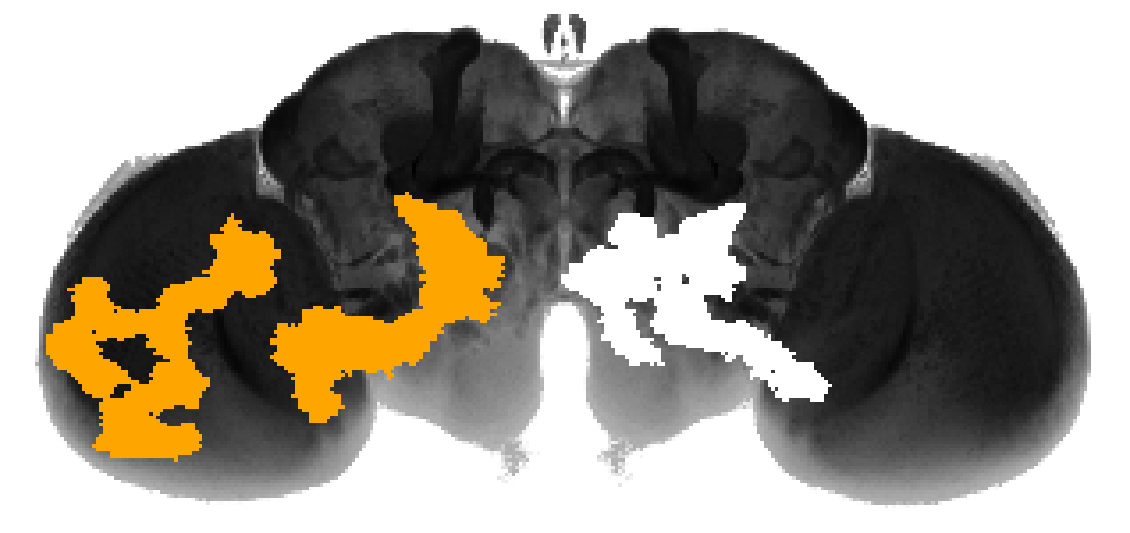

In [64]:
fig,ax=plt.subplots(figsize=(20,10))
ax.imshow(np.max(anat_lowres, axis=-1).T,cmap='gray_r');
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,common_values),giant_labels_anat,np.nan)
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=create_dark_to_color_cmap('orange'))
ax.axis('off');
# ax[1].imshow(np.max(anat_lowres, axis=-1).T,cmap='gray_r');
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,b2_un),giant_labels_anat,np.nan)
# ax[1].imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=create_dark_to_color_cmap(behavior_colors[b]))
# ax[1].axis('off');
# ax[2].imshow(np.max(anat_lowres, axis=-1).TZ,cmap='gray_r');
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,b3_uncommon),giant_labels_anat,np.nan)
# ax[2].imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=create_dark_to_color_cmap(behavior_colors[b]))
# ax[2].axis('off');
# plt.savefig(os.path.join(save_dir,f'top_overlap_cluster_loc.png'), dpi=300, bbox_inches='tight')

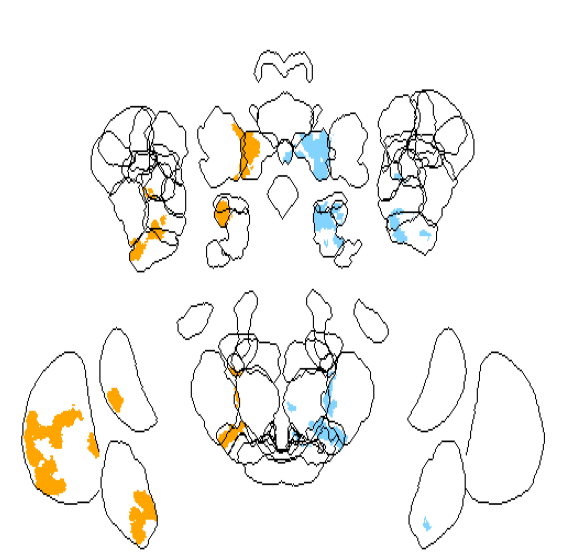

In [65]:
ax_as=1.5
vmax=np.nanmax(labels_anat_sub_total)
fig,axs=plt.subplots(figsize=(10,10))
temp=explode_plot(np.nan_to_num(labels_anat_sub_total),vmax,explosion_rois,roi_masks,roi_contours,cmap=create_dark_to_color_cmap('orange'))
brain=axs.imshow(temp[170:,:]) #this was made with cmap=hot
axs.axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
axs.set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'top_overlap_explosion.png'), dpi=300, bbox_inches='tight')

In [66]:
total_b=[b1_b.flatten().astype(int),b3_b.flatten().astype(int)]
common_movers=reduce(np.intersect1d,total_b)

In [67]:
common_movers.shape

(14,)

In [68]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [69]:
event1='new_best_5sec'
# event2='best'
n_clusters=500
label_files=[]
cluster_files=[]
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files.append(file)
    elif f'_{n_clusters}_' in file and 'clusters' in file and event1 in file:
        cluster_files.append(file)

## Load supervox

In [70]:
cluster_files

['superclust_clusters_500_new_best_5sec.pkl']

In [71]:
%%time
best_cluster_path_5sec=os.path.join(cluster_dir,cluster_files[0])
# best_cluster_path=os.path.join(cluster_dir,cluster_files[1])
print(best_cluster_path_5sec)
with open(best_cluster_path_5sec, 'rb') as file:
    five_sec = pickle.load(file)
    print(five_sec.keys())

# with open(best_cluster_path, 'rb') as file:
#     best = pickle.load(file)
#     print(best.keys())
    

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/superclust_clusters_500_new_best_5sec.pkl
dict_keys(['inc', 'dec', 'flat', 'non'])
CPU times: user 1.4 ms, sys: 0 ns, total: 1.4 ms
Wall time: 20.2 ms


In [72]:
label_files

['supercluster_labels_total_500.npy']

In [73]:
%%time
best_label_path=os.path.join(cluster_dir,label_files[0])
print(best_label_path)
giant_total_labels=np.load(best_label_path)
print(giant_total_labels.shape)

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/clustering/supercluster_labels_total_500.npy
(4171804,)
CPU times: user 6.26 ms, sys: 0 ns, total: 6.26 ms
Wall time: 6.42 ms


In [74]:
giant_total_anat=giant_total_labels.reshape(314,146,91)


In [75]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25']) #,  '#6d0d25'
# cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list(
#     'cmap', rainbow_color)
cmap_rainbow = matplotlib.colors.ListedColormap(rainbow_color)

In [76]:
giant_total_anat.shape

(314, 146, 91)

In [77]:
fixed = brainsss.load_fda_meanbrain()
behaviors=list(five_sec.keys())

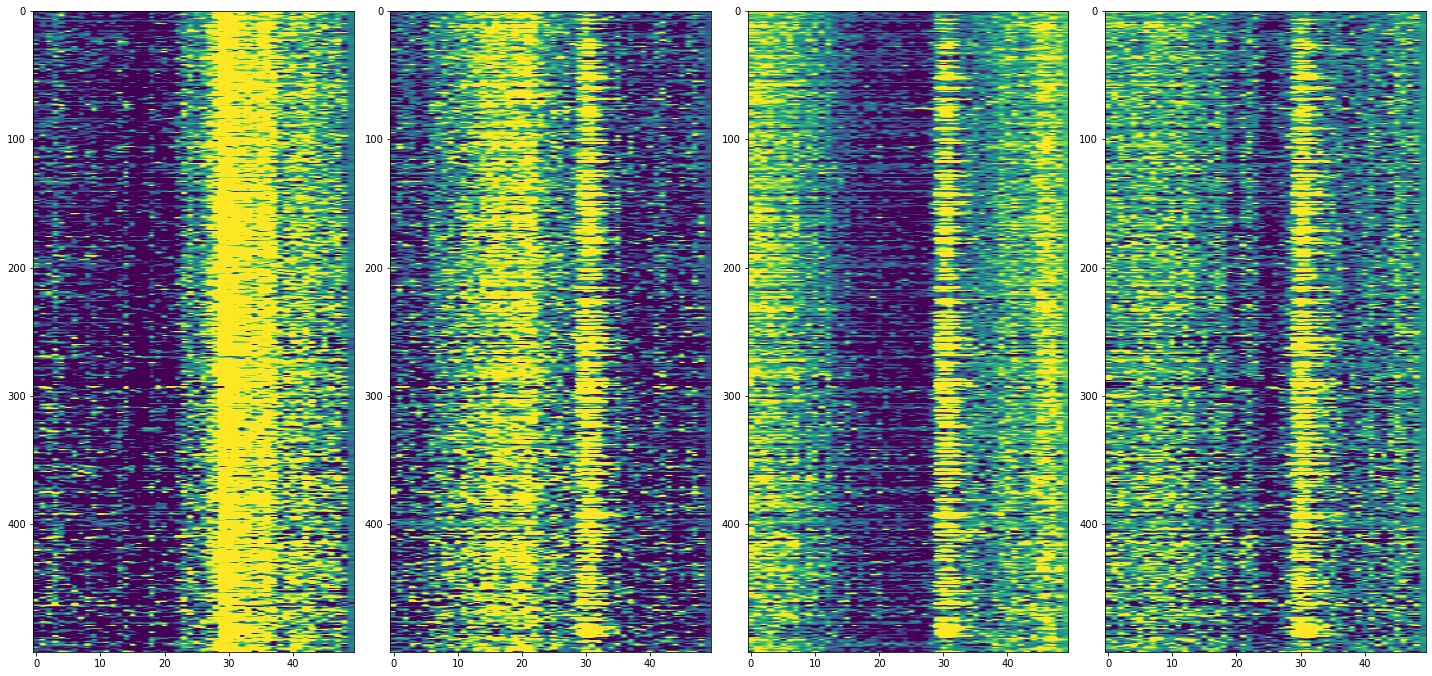

In [78]:
# ax_ap=0.1
# superclust_dict=best
# fig,axs=plt.subplots(1,3,figsize=(10,10))
# axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
# axs[0].set_aspect(ax_ap)
# axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
# axs[1].set_aspect(ax_ap)
# axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
# axs[2].set_aspect(ax_ap)
# plt.tight_layout()

ax_ap=0.2
start=15
end=40
superclust_dict=five_sec
fig,axs=plt.subplots(1,4,figsize=(20,10))
axs[0].imshow(superclust_dict['inc'], vmax=0.01,vmin=-0.01)
axs[0].set_aspect(ax_ap)
axs[1].imshow(superclust_dict['dec'],  vmax=0.01,vmin=-0.01)
axs[1].set_aspect(ax_ap)
axs[2].imshow(superclust_dict['flat'],  vmax=0.01,vmin=-0.01)
axs[2].set_aspect(ax_ap)
axs[3].imshow(superclust_dict['non'],  vmax=0.01,vmin=-0.01)
axs[3].set_aspect(ax_ap)
plt.tight_layout()

In [79]:
superclust_dict_z={}
for behavior in five_sec:
    print(behavior)
    signals_total_z=scipy.stats.zscore(five_sec[behavior][:,14:41],axis=1)
    superclust_dict_z[behavior]=signals_total_z

inc
dec
flat
non


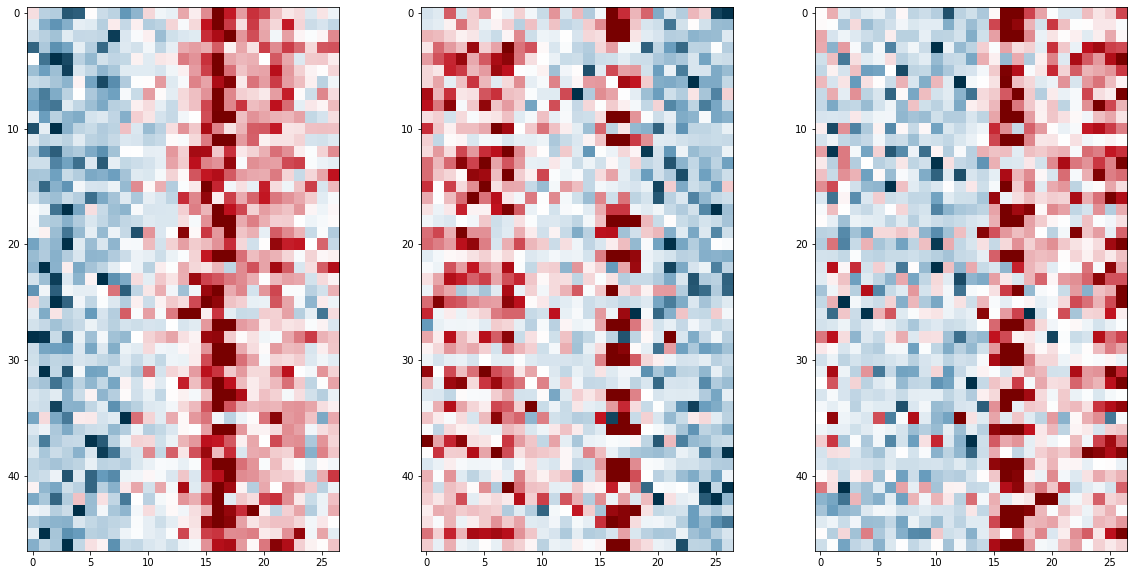

In [80]:
ax_ap=1
vmax=2
vmin=-2
clusters=np.asarray(b1_uncommon).astype(int)
# not_in=~np.isin(np.arange(500),rois)
fig,ax=plt.subplots(1,3,figsize=(20,10))
b='inc'
ax[0].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
b='dec'
ax[1].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
b='flat'
ax[2].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)

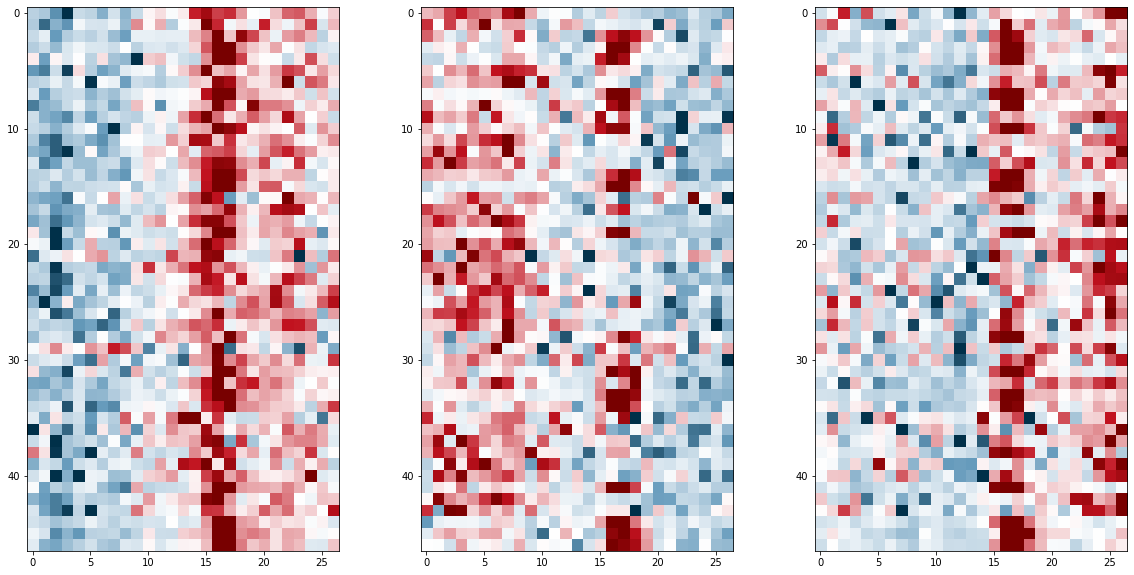

In [81]:
ax_ap=1
vmax=2
vmin=-2
clusters=np.asarray(b2_uncommon).astype(int)
# not_in=~np.isin(np.arange(500),rois)
fig,ax=plt.subplots(1,3,figsize=(20,10))
b='inc'
ax[0].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
b='dec'
ax[1].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
b='flat'
ax[2].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)

In [82]:
importance_df.head(4)['cluster']

1        1
69      69
104    104
145    145
Name: cluster, dtype: int64

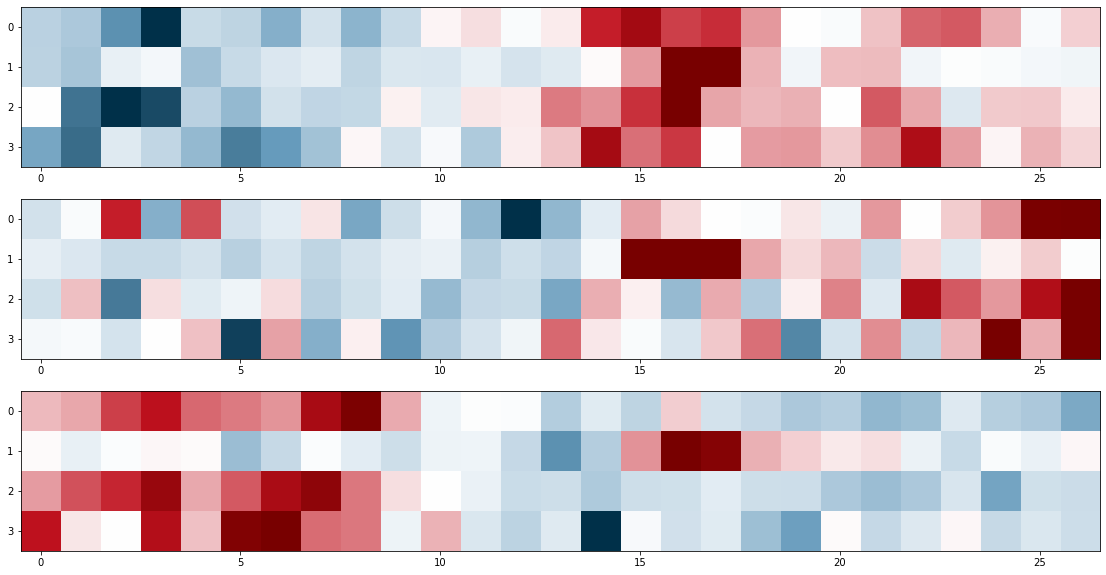

In [83]:
ax_ap=1
vmax=2
vmin=-2
clusters=list(importance_df.head(4)['cluster'])
# not_in=~np.isin(np.arange(500),rois)
fig,ax=plt.subplots(3,1,figsize=(20,10))
b='inc'
ax[0].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[0].set_aspect(ax_ap)
b='flat'
ax[1].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[1].set_aspect(ax_ap)
b='dec'
ax[2].imshow(superclust_dict_z[b][clusters,:],cmap=cmap_personal,vmax=vmax,vmin=vmin)
ax[2].set_aspect(ax_ap)
# plt.savefig(os.path.join(save_dir,f'commonvals_activity.png'), dpi=300, bbox_inches='tight')

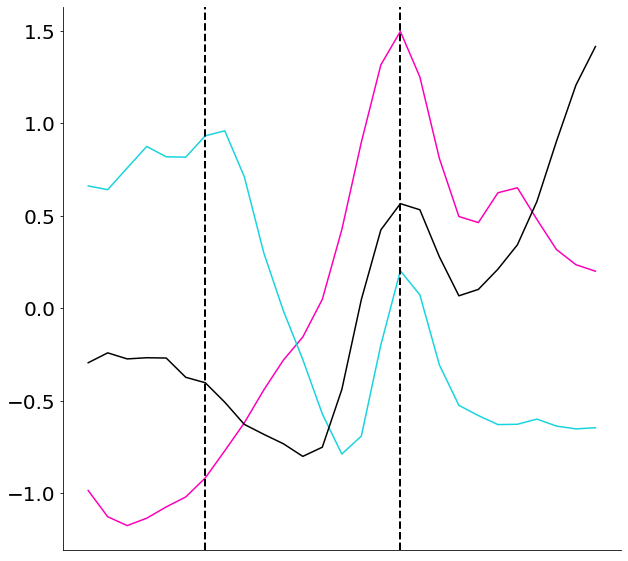

In [84]:
fig,axs=plt.subplots(figsize=(10,10))
# rois=best_clus_dict[comp]
behaves=['inc','dec','flat']
plot_dict=superclust_dict_z
for behave in behaves:
    avg_clus=gaussian_filter1d(np.mean(plot_dict[behave][clusters,:],axis=0),sigma=1)
    axs.plot(avg_clus,color=behavior_colors[behave], label=behave)
x1=6;x2=16
axs.axvline(x=x1, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=x2, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.set_xticks([])
axs.tick_params(axis='y', labelsize=20) 
# plt.savefig(os.path.join(save_dir,f'commonvals_time_trace.png'), dpi=300, bbox_inches='tight')

In [85]:
total_path = os.path.join(home_path, '10flies_total_dict.pkl')
with open(total_path, 'rb') as file:
    total_data_dict = pickle.load(file)

In [86]:
total_event_times_dic={}
total_trials={'inc':[],'dec':[],'flat':[],'non':[]}
total_idx={}
total_behavior={'total':[],'dec':[],'inc':[],'flat':[],'non':[]}
behave_lst={}
for fly in total_data_dict:
    total_event_times_dic[fly]={'inc':[],'dec':[],'flat':[],'non':[]}
    total_idx[fly]={'inc':[],'dec':[],'flat':[],'non':[]}
    fly_behavior=total_data_dict[fly]['behavior']
    looms=total_data_dict[fly]['event_times']
    behave_lst[fly]={'total':[],'label':[]}
    for i,trial in enumerate(fly_behavior):
    #     print(np.shape(trial))
        pre=np.mean(trial[150:200])
        post=np.mean(trial[250:300])
        total_behavior['total'].append([pre, post])
        behave_lst[fly]['total'].append([pre, post])
        if pre>-0.1 and pre<0.1 and post>-0.1 and post<0.1:
                total_event_times_dic[fly]['flat'].append(looms[i])
                total_trials['flat'].append(fly_behavior[i])
                total_behavior['flat'].append([pre, post])
                total_idx[fly]['flat'].append(i)
                b='flat'
        elif post>np.abs(pre*2):
                total_event_times_dic[fly]['inc'].append(looms[i])
                total_trials['inc'].append(fly_behavior[i])
                total_behavior['inc'].append([pre, post])
                total_idx[fly]['inc'].append(i)
                b='inc'
        elif post<pre/2:
                total_event_times_dic[fly]['dec'].append(looms[i])
                total_trials['dec'].append(fly_behavior[i])
                total_behavior['dec'].append([pre, post])
                total_idx[fly]['dec'].append(i)
                b='dec'
                
        else:
            total_event_times_dic[fly]['non'].append(looms[i])
            total_trials['non'].append(fly_behavior[i])
            total_behavior['non'].append([pre, post])
            total_idx[fly]['non'].append(i)
            b='non'
        behave_lst[fly]['label'].append(b)
    behave_lst[fly]['label']=np.asarray(behave_lst[fly]['label'])
    behave_lst[fly]['total']=np.asarray(behave_lst[fly]['total'])

In [87]:
behave_lst[fly]['total'].shape

(199, 2)

In [88]:
behave_lst[fly]['total'][0]

array([0.05009074, 0.07665834])

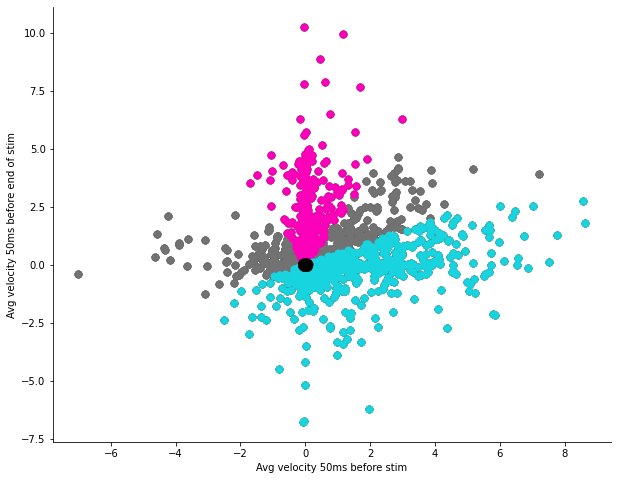

In [89]:
fig,axs=plt.subplots(figsize=(10, 8))
# plt.scatter(total_pre, total_post);
behavior_set=total_behavior
key_order=['total','non','inc','dec','flat']
for key in key_order:
#     print(key)
    if key is not 'total':
        axs.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=50,color=behavior_colors[key], label=key);
    else:
        axs.scatter(np.asarray(behavior_set[key])[:,0], np.asarray(behavior_set[key])[:,1], s=50, color='k', label=key);
        
# plt.axvline(0,color='k',linestyle='--',lw=2);
# plt.axhline(0,color='k',linestyle='--',lw=2);
# plt.legend();
axs.set_xlabel('Avg velocity 50ms before stim');
axs.set_ylabel('Avg velocity 50ms before end of stim');
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
# axs.spines['bottom'].set_visible(False)
# axs.spines['left'].set_visible(False)
# plt.savefig(os.path.join(save_dir,'total_avg_scatter.png'), dpi=300, bbox_inches='tight')

In [90]:
fly_clust.keys()

dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])

In [91]:
%%time
total_events_behave={}
for fly in fly_clust:
    print(f'fly is {fly}')
    total_events_behave[fly]={'vals':[],'label':[],'fv':[]}
    for cluster in fly_clust[fly]:
#         print(f'cluster is {cluster}')
        if cluster!=8:
            tempv=[]
            templ=[]
            tempf=[]
            for i,event in enumerate(behave_lst[str(fly)]['label']):
#                 print(f'event is {event}, and idx is {i}, and cluster is {cluster}')
                tempv.append(fly_clust[fly][cluster][i][-1])
                templ.append(event)
                tempf.append(behave_lst[str(fly)]['total'][i])
#                 print(np.shape(tempf))
            total_events_behave[fly]['vals'].append(tempv)
            total_events_behave[fly]['label'].append(templ)
    total_events_behave[fly]['vals']=np.vstack(total_events_behave[fly]['vals'])
    total_events_behave[fly]['label']=np.vstack(total_events_behave[fly]['label'])[0]
    total_events_behave[fly]['fv']=np.vstack(tempf)
#     total_events_behave[fly]['event_num']=np.vstack(total_events_behave[fly]['event_num'])

fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250
CPU times: user 1.44 s, sys: 56.7 ms, total: 1.5 s
Wall time: 1.49 s


In [92]:
total_events_behave[fly]['vals'].shape

(499, 199)

In [93]:
predictions=[]
behave=[]
for fly in total_events_behave:
    fly_predict=rf.predict(total_events_behave[fly]['vals'].T)
    predictions.append(fly_predict)
    behave.append(total_events_behave[fly]['fv'])
predictions=np.hstack(predictions)
behave=np.vstack(behave)
print(predictions.shape,behave.shape)

(1982,) (1982, 2)


In [94]:
scatter_colors=[]
for event in predictions:
    scatter_colors.append(behavior_colors[event])
scatter_colors=np.asarray(scatter_colors)

In [95]:
predictions_without=predictions[~np.isin(np.arange(np.shape(predictions)[0]),train_indices)]
behave_without=behave[~np.isin(np.arange(np.shape(behave)[0]),train_indices)]
color_without=scatter_colors[~np.isin(np.arange(np.shape(scatter_colors)[0]),train_indices)]

In [96]:
predictions_without.shape

(1670,)

In [97]:
np.unique(predictions_without)

array(['dec', 'flat', 'inc'], dtype='<U4')

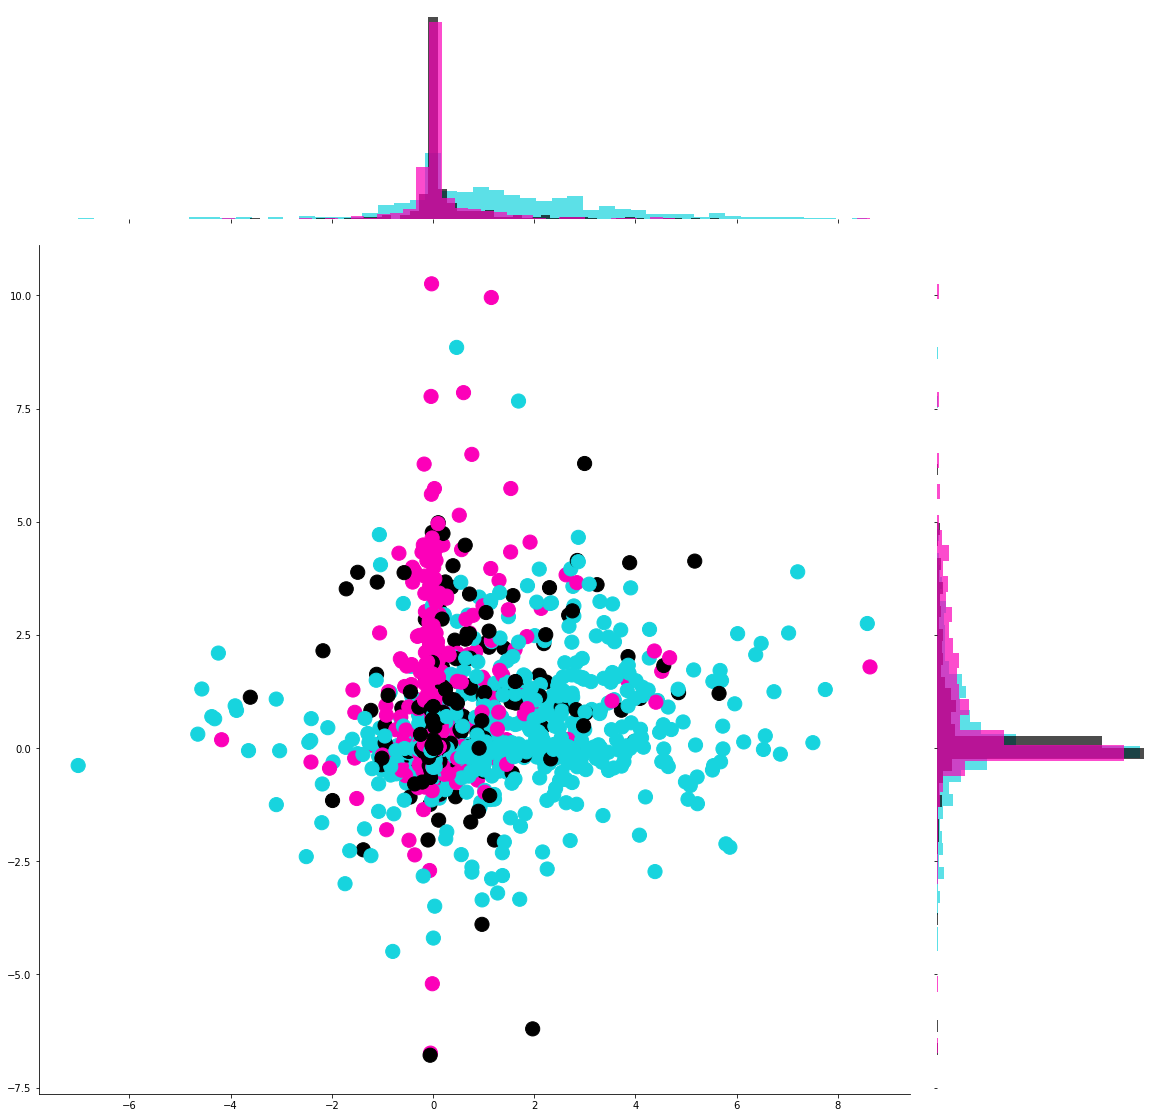

In [98]:
fig = plt.figure(figsize=(20, 20))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                      hspace=0.05, wspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
# plt.scatter(total_pre, total_post);
behavior_set=behave_without

ax_main.scatter(np.asarray(behavior_set)[:,0], np.asarray(behavior_set)[:,1], s=200,color=color_without,label=key);
    
        
# plt.axvline(0,color='k',linestyle='--',lw=2);
# plt.axhline(0,color='k',linestyle='--',lw=2);
# plt.legend();
# ax_main.set_xlabel('Avg velocity 50ms before stim');
# ax_main.set_ylabel('Avg velocity 50ms before end of stim');
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)

ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
for b in np.unique(predictions_without):
    x=np.asarray(behavior_set)[:,0][predictions_without==b]
    ax_top.hist(x, bins=50, color=behavior_colors[b], alpha=0.7)
ax_top.tick_params(labelbottom=False)
ax_top.set_yticks([])
# ax_top.set_xticks([])
# ax_top.set_ylabel('De')
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.spines['left'].set_visible(False)
ax_top.spines['bottom'].set_visible(False)

ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
for b in np.unique(predictions_without):
    y=np.asarray(behavior_set)[:,1][predictions_without==b]
    ax_right.hist(y, bins=50, color=behavior_colors[b], alpha=0.7, orientation='horizontal')
ax_right.tick_params(labelleft=False)
# ax_right.set_yticks([])
ax_right.set_xticks([])
# ax_right.set_xlabel('Count')
ax_right.spines['top'].set_visible(False)
ax_right.spines['right'].set_visible(False)
ax_right.spines['bottom'].set_visible(False)
ax_right.spines['left'].set_visible(False)
# plt.savefig(os.path.join(save_dir,'model_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()


In [99]:
print(f'inc: {np.count_nonzero(predictions_without=="inc")}')
print(f'dec: {np.count_nonzero(predictions_without=="dec")}')
print(f'flat: {np.count_nonzero(predictions_without=="flat")}')

inc: 510
dec: 637
flat: 523


In [100]:
importance_df['importance']

1      0.016109
69     0.015653
104    0.011530
145    0.011472
56     0.010700
         ...   
194    0.000272
31     0.000221
96     0.000171
339    0.000149
232    0.000137
Name: importance, Length: 499, dtype: float64

In [44]:
%%time

dict_to_look = sep_events
ids=[56,  69,  47, 145, 131,  65,  12, 162, 207,   1, 173, 496, 169,
       316, 104,  62,  10, 137, 334,  57, 271, 103, 247,  11, 367, 115,
        78, 381,  53, 114, 280, 227, 152, 195, 425, 488,   8, 198, 288,
        43, 349, 266, 223,  86, 210, 218, 421,  40, 413, 299, 474, 378,
       186, 429,  16,  37, 435, 102, 379, 161,  14, 279, 277, 213, 101,
       407, 426, 233, 406,  28, 454, 206, 436, 304, 284, 281, 184, 376,
       302,  98,  80, 146, 226,  22, 244,  18,  19, 258,  89, 388, 344,
        95, 200, 364, 276, 318, 283,  63, 309, 219]
amt=[0,5,10,20,30,40,50,60,70,80,90,100]
# Create full X and y
scores={'train':[],'test':[],'null':[]}
for a in amt:
    i=ids[:a]
    X = []
    y = dict_to_look[0]['label']
    for cluster in range(500):
        if cluster != 8:
            X.append(dict_to_look[cluster]['vals'])

    X = np.hstack(X)
    y = np.array(y)

    # Get cluster importance weights
    # cluster_weights = (importance_df['importance'][np.arange(np.shape(importance_df['importance'])[0])]) * 500
    # cluster_weights[cluster_weights <= 1] = 1
    # cluster_weights = np.array(cluster_weights)
    summed = np.sum(X[:, i], axis=-1, keepdims=True) 
    X = np.hstack([X, summed])  # Add as a new column

    num_permutations = 1000
    train_scores_total = []
    test_scores_total = []
    null_scores_total = []

    for n in range(num_permutations):
        # ONE train/test split
        train_indices, test_indices = train_test_split(
            np.arange(len(y)), 
            test_size=0.2, 
            random_state=n, 
            stratify=y
        )

        X_train = X[train_indices,:]
        X_test = X[test_indices,:]
        y_train = y[train_indices]
        y_test = y[test_indices]

        # Standardize first
    #     scaler = StandardScaler()
    #     X_train_scaled = scaler.fit_transform(X_train)
    #     X_test_scaled = scaler.transform(X_test)

    #     print('here')
        # THEN multiply by cluster weights (amplify important clusters)
    #     X_train_weighted = X_train_scaled #* cluster_weights[np.newaxis,:]
    #     X_test_weighted = X_test_scaled #* cluster_weights[np.newaxis,:]

        # Fit ONE model on ALL weighted clusters together
        model = LogisticRegression(max_iter=1000, multi_class='multinomial', C=10)
        model.fit(X_train, y_train)

        # Get scores
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)

        # Null accuracy
        y_null = np.random.choice(model.classes_, size=len(y_test))
        null_acc = model.score(X_test, y_null)

        train_scores_total.append(train_acc)
        test_scores_total.append(test_acc)
        null_scores_total.append(null_acc)
    scores['train'].append(train_scores_total)
    scores['test'].append(test_scores_total)
    scores['null'].append(null_scores_total)

# print(f"Mean train accuracy: {np.mean(train_scores_total):.3f}")
# print(f"Mean test accuracy: {np.mean(test_scores_total):.3f}")
# print(f"Mean null accuracy: {np.mean(null_scores_total):.3f}")

CPU times: user 1h 25min 58s, sys: 8h 5min 9s, total: 9h 31min 8s
Wall time: 19min 51s


In [45]:
# file_path=os.path.join(cluster_dir, 'log_regress_set.pkl')
# with open(file_path, 'wb') as file:
#         pickle.dump(scores, file)

In [50]:
mean_train=np.mean(scores['train'], axis=-1)
std_train=np.std(scores['train'], axis=-1)
mean_test=np.mean(scores['test'], axis=-1)
std_test=np.std(scores['test'], axis=-1)
mean_null=np.mean(scores['null'], axis=-1)
std_null=np.std(scores['null'], axis=-1)
x=np.asarray(amt)

<ErrorbarContainer object of 3 artists>

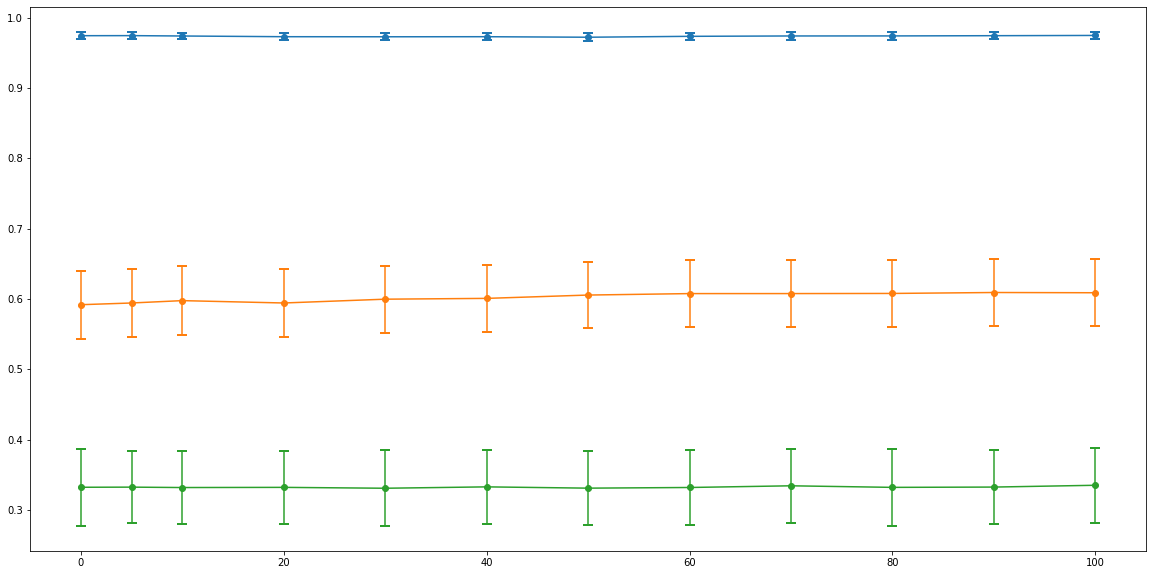

In [51]:
fig,ax=plt.subplots(figsize=(20,10))
ax.errorbar(x, mean_train, yerr=std_train, fmt='o-', capsize=5, capthick=2)
ax.errorbar(x, mean_test, yerr=std_test, fmt='o-', capsize=5, capthick=2)
ax.errorbar(x, mean_null, yerr=std_null, fmt='o-', capsize=5, capthick=2)

In [27]:
# %%time

# dict_to_look = sep_events

# # Create full X and y
# X = []
# y = dict_to_look[0]['label']
# for cluster in range(500):
#     if cluster != 8:
#         X.append(dict_to_look[cluster]['vals'])

# X = np.hstack(X)
# y = np.array(y)

# # Get cluster importance weights
# # cluster_weights = (importance_df['importance'][np.arange(np.shape(importance_df['importance'])[0])]) * 500
# # cluster_weights[cluster_weights <= 1] = 1
# cluster_weights = np.ones(499)

# num_permutations = 1000
# no_weight_train_scores_total = []
# no_weight_test_scores_total = []
# no_weight_null_scores_total = []

# for n in range(num_permutations):
#     # ONE train/test split
#     train_indices, test_indices = train_test_split(
#         np.arange(len(y)), 
#         test_size=0.2, 
#         random_state=n, 
#         stratify=y
#     )
    
#     X_train = X[train_indices,:]
#     X_test = X[test_indices,:]
#     y_train = y[train_indices]
#     y_test = y[test_indices]
    
#     # Standardize first
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
# #     print('here')
#     # THEN multiply by cluster weights (amplify important clusters)
#     X_train_weighted = X_train_scaled * cluster_weights[np.newaxis,:]
#     X_test_weighted = X_test_scaled * cluster_weights[np.newaxis,:]
    
#     # Fit ONE model on ALL weighted clusters together
#     model = LogisticRegression(max_iter=1000, multi_class='multinomial', C=10)
#     model.fit(X_train_weighted, y_train)
    
#     # Get scores
#     train_acc = model.score(X_train_weighted, y_train)
#     test_acc = model.score(X_test_weighted, y_test)
    
#     # Null accuracy
#     y_null = np.random.choice(model.classes_, size=len(y_test))
#     null_acc = model.score(X_test_weighted, y_null)
    
#     no_weight_train_scores_total.append(train_acc)
#     no_weight_test_scores_total.append(test_acc)
#     no_weight_null_scores_total.append(null_acc)

# print(f"Mean train accuracy: {np.mean(no_weight_train_scores_total):.3f}")
# print(f"Mean test accuracy: {np.mean(no_weight_test_scores_total):.3f}")
# print(f"Mean null accuracy: {np.mean(no_weight_null_scores_total):.3f}")

Mean train accuracy: 1.000
Mean test accuracy: 0.559
Mean null accuracy: 0.333
CPU times: user 5min 22s, sys: 23min 9s, total: 28min 32s
Wall time: 58.3 s


In [175]:
# %%time

# dict_to_look = sep_events

# # Create full X and y
# X = []
# y = dict_to_look[0]['label']
# for cluster in range(500):
#     if cluster != 8:
#         X.append(dict_to_look[cluster]['vals'])

# X = np.hstack(X)
# y = np.array(y)

# # Get cluster weights (not sample weights!)
# cluster_weights = (importance_df['importance'][np.arange(np.shape(importance_df['importance'])[0])]) * 500
# cluster_weights[cluster_weights <= 1] = 1

# num_permutations = 1000
# train_scores_total = []
# test_scores_total = []
# null_scores_total = []

# for n in range(num_permutations):
#     # ONE train/test split
#     train_indices, test_indices = train_test_split(
#         np.arange(len(y)), 
#         test_size=0.2, 
#         random_state=n, 
#         stratify=y
#     )
    
#     # Store predictions from each cluster
#     train_preds_all_clusters = []
#     test_preds_all_clusters = []
    
#     for cluster in range(np.shape(X)[-1]):
#         X_cluster = X[:, cluster].reshape(-1, 1)
        
#         X_train = X_cluster[train_indices]
#         X_test = X_cluster[test_indices]
#         y_train = y[train_indices]
#         y_test = y[test_indices]
        
#         # Standardize
#         scaler = StandardScaler()
#         X_train_scaled = scaler.fit_transform(X_train)
#         X_test_scaled = scaler.transform(X_test)
        
#         # Fit model WITHOUT sample weights
#         model = LogisticRegression(max_iter=1000, multi_class='multinomial', C=10)
#         model.fit(X_train_scaled, y_train)
        
#         # Get probability predictions
#         train_preds_all_clusters.append(model.predict_proba(X_train_scaled))
#         test_preds_all_clusters.append(model.predict_proba(X_test_scaled))
    
#     # Now apply CLUSTER weights to combine predictions
#     train_preds_all_clusters = np.array(train_preds_all_clusters)  # (n_clusters, n_train, n_classes)
#     test_preds_all_clusters = np.array(test_preds_all_clusters)    # (n_clusters, n_test, n_classes)
    
#     # Weighted average across clusters
#     train_preds_weighted = np.average(train_preds_all_clusters, axis=0, weights=cluster_weights)
#     test_preds_weighted = np.average(test_preds_all_clusters, axis=0, weights=cluster_weights)
    
#     # Get final predictions
#     train_pred_labels = model.classes_[np.argmax(train_preds_weighted, axis=1)]
#     test_pred_labels = model.classes_[np.argmax(test_preds_weighted, axis=1)]
    
#     # Calculate accuracies
#     train_acc = np.mean(train_pred_labels == y[train_indices])
#     test_acc = np.mean(test_pred_labels == y[test_indices])
    
#     # Null accuracy
#     y_null = np.random.choice(model.classes_, size=len(y_test))
#     null_acc = np.mean(test_pred_labels == y_null)
    
#     train_scores_total.append(train_acc)
#     test_scores_total.append(test_acc)
#     null_scores_total.append(null_acc)

# print(f"Mean train accuracy: {np.mean(train_scores_total):.3f}")
# print(f"Mean test accuracy: {np.mean(test_scores_total):.3f}")
# print(f"Mean null accuracy: {np.mean(null_scores_total):.3f}")

Mean train accuracy: 0.548
Mean test accuracy: 0.590
Mean null accuracy: 0.333
CPU times: user 23min 46s, sys: 4.77 s, total: 23min 51s
Wall time: 23min 51s


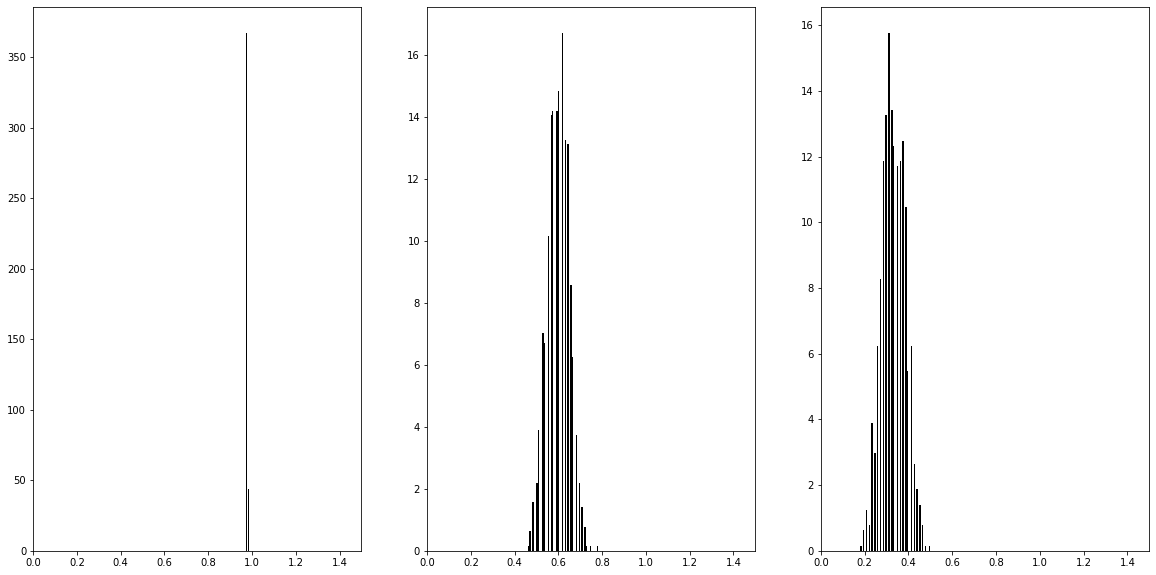

In [43]:
bins=50
fig,ax=plt.subplots(1,3,figsize=(20,10))
ax[0].hist(train_scores_total, bins=bins,density=True, color='k');
# ax[0].hist(no_weight_train_scores_total, bins=bins,density=True, color='r');
# ax[0].set_ylim(0,10);
ax[0].set_xlim(0,1.5);
ax[1].hist(test_scores_total, bins=bins, density=True,color='k');
# ax[1].hist(no_weight_test_scores_total, bins=bins, density=True,color='r');
# ax[1].set_ylim(0,10);
ax[1].set_xlim(0,1.5);
ax[2].hist(null_scores_total, bins=bins, density=True,color='k');
# ax[2].hist(no_weight_null_scores_total, bins=bins, density=True,color='r');
ax[2].set_xlim(0,1.5);